In [ ]:
!pip install tensorflow

### Step 1: Setting up the Environment and Importing Libraries

**Code Cells:**
- `7d25389e-e3e0-415f-bd80-86951db5fd81`: `!pip install tensorflow`
- `5ab7262f`: `!pip install scikit-learn`
- `699ef5ad`: Import statements for various libraries (os, random, numpy, pandas, seaborn, PIL, pathlib, tensorflow, keras, matplotlib, sklearn modules).

**Purpose:**
This initial step prepares the environment by ensuring all necessary libraries are installed and imported. `tensorflow` and `scikit-learn` are fundamental for building and evaluating machine learning models, especially deep learning and traditional ML metrics, respectively. The various `import` statements bring in functions and classes for data manipulation (pandas, numpy), image processing (PIL, tensorflow.keras.preprocessing.image), model building (tensorflow.keras), visualization (matplotlib, seaborn), and utility functions (os, random, pathlib).

**Output and Contribution:**
- **Standard Output:** Shows messages like `Requirement already satisfied`, indicating successful installation or that the packages are already present.
- **Contribution:** Establishes the foundational toolkit for the entire project, making all subsequent functions and classes available for use. Without this step, no other code related to these libraries would run.

### Step 2: Reproducibility and Global Variable Definition

**Code Cells:**
- `76195b07`: `tf.random.set_seed(5638)`, `random.seed(5638)`
- `4950db87`: Variable definitions for `EPOCHS`, `BATCH_SIZE`, `IMG_SIZE`, `IMAGE_SIZE`, `DIM`.

**Purpose:**
- **Seed Setting:** Setting random seeds for TensorFlow and the standard `random` module ensures that any random operations (like data shuffling or weight initialization) are consistent across different runs. This is crucial for reproducibility, allowing the same results to be obtained if the code is run again.
- **Global Variables:** Defining global variables like `EPOCHS`, `BATCH_SIZE`, and `IMG_SIZE` centralizes important hyperparameters. This makes them easy to modify in one place, affecting the entire model training process.

**Output and Contribution:**
- **Standard Output:** No direct visible output is generated by these cells.
- **Contribution:**
  - **Reproducibility:** Guarantees that the experiments can be replicated, which is vital for validating results and debugging.
  - **Configurability:** Provides a clear and efficient way to manage key parameters that control model training and data processing.

### Step 3: Data Loading, Preprocessing, and Augmentation Setup

**Code Cell:**
- `1da819ae`: This cell handles locating image files, organizing them into DataFrames, and setting up `ImageDataGenerator` for efficient data loading and preprocessing during training and testing.

**Purpose:**
This is a critical data preparation step. It involves:
1.  **Defining Data Paths:** Specifies the locations of the training and testing image directories.
2.  **Listing Filepaths and Labels:** Iterates through the directories to collect all image file paths and extracts their corresponding labels (e.g., 'MildDemented', 'NonDemented') from the folder names.
3.  **Creating DataFrames:** Organizes the file paths and labels into pandas DataFrames (`train_df`, `test_df`). These DataFrames are then shuffled.
4.  **`ImageDataGenerator` Setup:** Initializes TensorFlow's `ImageDataGenerator` objects for both training and testing. These generators perform:
    *   **Rescaling:** Normalizes pixel values by dividing by 255.0, scaling them to the range `[0, 1]`.
    *   **`flow_from_dataframe`:** Creates `DirectoryIterator` objects (`train_images`, `validation_images`, `test_images`) that efficiently load images in batches directly from the DataFrames, apply preprocessing, and serve them to the model during training and evaluation. It also automatically infers classes from the labels.

**Output and Contribution:**
-   **Standard Output:**
    *   `Train directory exists: True`, `Test directory exists: True`: Confirmation that the data directories are accessible.
    *   `Training samples: 33984`, `Testing samples: 1279`: Shows the total number of images found in each set.
    *   `train_df.head(3)`, `test_df.head(3)`: Displays the first few rows of the generated DataFrames, confirming correct file path and label extraction.
    *   `Training class distribution`, `Testing class distribution`: Provides a breakdown of the number of samples per class in the training and testing sets, which is crucial for understanding class balance.
    *   `Found X validated image filenames belonging to Y classes.`: Confirms that `flow_from_dataframe` successfully identified images and classes.
    *   `Class indices: {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}`: Maps class names to numerical indices, which the model uses internally.
-   **Contribution:**
    *   **Structured Data:** Organizes raw image file paths into structured DataFrames, making them usable by TensorFlow's data generators.
    *   **Efficient Data Pipelining:** Creates data generators that feed images to the model in batches, handling image resizing, color mode conversion, and one-hot encoding of labels automatically.
    *   **Preprocessing:** Normalizes image data, which is essential for stable and effective neural network training.
    *   **Dataset Split:** Implicitly creates a training and validation split using `validation_split` in `train_generator`.

### Step 4: Custom CNN Model Definition and Compilation

**Code Cell:**
- `9e630b0d` (Model definition part): Defines a custom Convolutional Neural Network (CNN) architecture using Keras Sequential API.
- `9e630b0d` (Model compilation part): Configures the model for training with an optimizer, loss function, and evaluation metrics.

**Purpose:**
-   **Model Architecture:** This section constructs the neural network. It consists of multiple layers designed to extract features from images and classify them into one of the four Alzheimer's disease categories. Key layers include:
    *   `Conv2D`: Convolutional layers for feature extraction.
    *   `MaxPool2D`: Downsamples feature maps, reducing dimensionality.
    *   `BatchNormalization`: Stabilizes and accelerates training by normalizing layer inputs.
    *   `Flatten`: Converts 2D feature maps into a 1D vector.
    *   `Dropout`: Regularization technique to prevent overfitting by randomly setting a fraction of input units to zero during training.
    *   `Dense`: Fully connected layers for classification.
    *   `Softmax Activation`: Outputs probabilities for each class.
-   **Model Compilation:** This step prepares the model for training by specifying:
    *   `Optimizer (Adam)`: The algorithm used to adjust model weights during training to minimize the loss function.
    *   `Loss Function (CategoricalCrossentropy)`: Measures how well the model's predicted probabilities match the true labels (suitable for multi-class classification).
    *   `Metrics`: Additional metrics to monitor during training and evaluation (`accuracy`, `AUC`, `F1-Score`).

**Output and Contribution:**
-   **Standard Output (`custom_model.summary()`):**
    *   Prints a detailed table outlining each layer in the model: layer name, output shape, and number of parameters. This provides a clear overview of the model's structure and complexity.
    *   `Total params`, `Trainable params`, `Non-trainable params`: Summarizes the total number of weights and biases in the model, distinguishing between those that will be updated during training and those that remain fixed.
-   **Contribution:**
    *   **Model Blueprint:** Creates the convolutional neural network that will learn patterns from the image data.
    *   **Training Configuration:** Sets up how the model will learn (optimizer), what it aims to optimize (loss function), and how its performance will be measured (metrics).

### Step 5: Model Training and Evaluation

**Code Cell:**
- `9e630b0d` (Training and initial evaluation part): Executes the training process and performs an initial evaluation on the test set.

**Purpose:**
-   **Model Training (`custom_model.fit`):** This is where the model learns from the training data. It iteratively adjusts its internal weights and biases to minimize the loss function, using the `train_images` for training and `validation_images` for monitoring performance on unseen data. `EPOCHS` defines the number of full passes over the training dataset.
    *   **Callbacks:** `EarlyStopping` prevents overfitting by stopping training if validation loss doesn't improve for a certain number of epochs (`patience`). `ModelCheckpoint` saves the model's weights whenever a new best validation loss is achieved.
-   **Initial Model Evaluation (`custom_model.evaluate`):** After training, the model's performance is assessed on the `test_images` dataset, which it has never seen before. This provides an unbiased estimate of its generalization capability.
-   **Prediction (`custom_model.predict`):** Generates probability predictions for each class on the test set. These probabilities are then converted into discrete class labels using `np.argmax`.

**Output and Contribution:**
-   **Standard Output (`custom_model.fit`):**
    *   **Epoch-wise Metrics:** For each epoch, it prints the training loss, accuracy, AUC, F1-score, and the corresponding validation metrics (`val_loss`, `val_acc`, `val_auc`, `val_f1_score`). This allows monitoring the learning progress and identifying potential overfitting.
    *   `Epoch X: val_loss improved from ... to ..., saving model to ...`: Messages from `ModelCheckpoint` indicating when the best model weights are saved.
    *   `Epoch X: early stopping`: If early stopping condition is met, it indicates the training halted before all epochs completed.
-   **Standard Output (`custom_model.evaluate`):**
    *   `Testing Accuracy: X.YY%`: Reports the final accuracy of the model on the unseen test dataset.
-   **Contribution:**
    *   **Learned Model:** Produces the trained neural network model capable of classifying Alzheimer's disease stages from MRI images.
    *   **Performance Metrics:** Provides key performance indicators (accuracy, loss, AUC, F1-score) during training and on the test set, allowing for an assessment of the model's effectiveness and learning behavior.

### Step 6: Detailed Classification Report and Confusion Matrix Visualization

**Code Cell:**
- `9e630b0d` (Classification report and confusion matrix visualization part): Generates a text-based classification report and visualizes the confusion matrix.

**Purpose:**
-   **`classification_report`:** Provides a comprehensive summary of precision, recall, and F1-score for each class, as well as overall averages (macro and weighted average). This helps in understanding the model's performance across different classes, especially in imbalanced datasets.
    *   **Precision:** The proportion of positive identifications that were actually correct.
    *   **Recall:** The proportion of actual positives that were identified correctly.
    *   **F1-score:** The harmonic mean of precision and recall, providing a balanced measure.
-   **Confusion Matrix:** A table that summarizes the performance of a classification algorithm. Each row represents the instances in an actual class, while each column represents the instances in a predicted class. It helps visualize how well the model distinguishes between different classes and identifies specific types of errors (e.g., false positives, false negatives).
    *   The heatmap visualization makes it easy to spot patterns in correct and incorrect classifications.

**Output and Contribution:**
-   **Standard Output (`classification_report`):**
    *   A formatted table showing `precision`, `recall`, `f1-score`, and `support` (number of true instances) for each class, along with `accuracy`, `macro avg`, and `weighted avg`.
-   **Plot Output (Confusion Matrix Heatmap):**
    *   A visually intuitive heatmap where colors indicate the number of predictions in each cell, with class labels on the axes. This immediately highlights which classes are well-predicted and where confusion occurs.
-   **Contribution:**
    *   **In-depth Performance Analysis:** Goes beyond overall accuracy to provide a granular view of the model's strengths and weaknesses for each class.
    *   **Error Identification:** Helps in identifying specific misclassification patterns, which is crucial for model improvement (e.g., if one class is consistently mistaken for another).

### Step 7: Additional Key Metrics and Model Saving

**Code Cell:**
- `3ce6ed73-0cf6-44fb-8d73-17fc7c7a79f7`: Calculates Balanced Accuracy Score and Matthews Correlation Coefficient, and saves the trained model.

**Purpose:**
-   **Balanced Accuracy Score (BAS):** This metric is particularly useful for imbalanced datasets. It's the average of recall obtained on each class, providing a more fair assessment of performance when some classes have many more samples than others.
-   **Matthews Correlation Coefficient (MCC):** A single, comprehensive metric that takes into account true positives, true negatives, false positives, and false negatives. It is considered a balanced measure even if the classes are of very different sizes. MCC ranges from -1 (total disagreement) to +1 (perfect prediction), with 0 indicating random prediction.
-   **Model Saving:** Persists the trained model to a file (`.h5` format). This allows the model to be loaded and used later for predictions without needing to retrain it.

**Output and Contribution:**
-   **Standard Output:**
    *   `Balanced Accuracy Score: X.YY%`: The calculated balanced accuracy.
    *   `Matthew's Correlation Coefficient: X.YY%`: The calculated MCC.
-   **File Output:**
    *   A file named `custom_cnn_(87.04%).h5` (the name might vary based on the actual accuracy achieved) is created, containing the model's architecture, weights, and training configuration.
-   **Contribution:**
    *   **Robust Evaluation:** Provides additional robust metrics that are less sensitive to class imbalance, offering a more complete picture of the model's performance.
    *   **Model Deployment/Reuse:** Allows the trained model to be easily deployed or reused for future predictions without the need for retraining, saving computational resources and time.

### Step 8: Comprehensive Model Analysis and Visualization (Advanced Metrics)

**Code Cells:**
- `3c29db68`: Defines multiple functions for detailed analysis and visualization (`plot_roc_curve`, `plot_enhanced_confusion_matrix`, `plot_training_history`, `plot_all_metrics`, `analyze_predictions`).
- `4598e072-2377-425f-bc8b-7421ae9cecab`: Defines additional analysis functions (`comprehensive_model_analysis`, `confidence_analysis`, `advanced_classification_metrics`, `per_class_analysis`, `confidence_distribution`, `calibration_analysis`, `error_analysis`, `training_analysis`, `calculate_confidence_intervals`, `model_complexity_analysis`) and then calls `comprehensive_model_analysis` and other analyses.

**Purpose:**
These cells provide an extensive suite of tools for in-depth model understanding, going far beyond basic accuracy. They aim to answer questions about:
1.  **ROC Curve:** Visualizes the trade-off between true positive rate and false positive rate across different thresholds for each class, providing an `Area Under the Curve (AUC)` value to quantify overall discriminative power.
2.  **Enhanced Confusion Matrix:** Offers both raw counts and normalized percentages to show prediction accuracy and specific misclassification patterns more clearly.
3.  **Training History Graphs:** Plots training and validation metrics (accuracy, loss, AUC, F1-score) over epochs, essential for diagnosing overfitting, underfitting, and convergence.
4.  **Prediction Analysis:** Identifies and lists specific misclassified samples, providing insights into where the model struggles.
5.  **Confidence Analysis:** Examines the model's predicted probabilities, comparing confidence levels for correct vs. incorrect predictions.
6.  **Advanced Classification Metrics:** Includes Cohen's Kappa, Log Loss, Hamming Loss, Jaccard Score, and Average Precision, providing a multifaceted view of classification quality.
7.  **Per-Class Detailed Analysis:** Tabulates precision, recall, F1-score, support, and average confidence for each individual class.
8.  **Confidence Distribution:** Visualizes how confidence scores are distributed across different classes and prediction outcomes.
9.  **Model Calibration Analysis:** Assesses whether the model's predicted probabilities are reliable (i.e., if a prediction of 80% confidence actually means an 80% chance of being correct).
10. **Error Analysis:** Further investigates misclassifications, identifying common confusion pairs and examining errors based on confidence.
11. **Training Process Analysis:** Quantifies overfitting by comparing final training and validation metrics.
12. **Confidence Intervals:** Provides a range within which the true accuracy of the model is likely to fall.
13. **Model Complexity Analysis:** Reports the number of total, trainable, and non-trainable parameters, giving an idea of the model's size and computational requirements.

**Output and Contribution:**
-   **Standard Output:** A wealth of textual output providing quantitative metrics for all the analyses listed above, including:
    *   Cohen's Kappa, Log Loss, Hamming Loss, Jaccard Score (macro and per-class), Average Precision (macro and per-class), Balanced Accuracy.
    *   Confidence statistics (mean, std, min, max) overall and for correct/incorrect predictions.
    *   Accuracy and coverage at different confidence thresholds.
    *   Per-class precision, recall, F1-score, support, and average confidence.
    *   Expected Calibration Error for each class.
    *   List of most common misclassifications (e.g., "VeryMildDemented → NonDemented: X samples").
    *   Statistics on low confidence correct vs. high confidence errors.
    *   Final training/validation accuracy/loss, and calculated accuracy/loss gaps.
    *   Accuracy Confidence Interval.
    *   Model complexity (total, trainable, non-trainable parameters).
    *   List of misclassified samples with true/predicted labels and confidence.
-   **Plot Outputs:**
    *   **Multi-class ROC Curve:** A line plot for each class, showing its ROC curve and AUC score.
    *   **Enhanced Confusion Matrices:** Two heatmaps (one with counts, one normalized by percentage).
    *   **Training History Graphs:** Plots of accuracy, loss, AUC, and F1-score for both training and validation sets over epochs.
    *   **Overall Confidence Distribution Histogram.**
    *   **Confidence Distribution by Prediction Outcome (Correct/Incorrect) Histograms.**
    *   **Confidence Distribution by True Class Histograms and Box Plots.**
    *   **Calibration Plots** for each class.
    *   **Error Matrix Heatmap.**
-   **File Output:** The model is saved again with its final test accuracy in the filename (e.g., `custom_cnn_(98.59%).h5`).

**Contribution:**
-   **Deep Insights:** Provides a holistic and granular understanding of the model's performance, behavior, and potential biases or weaknesses.
-   **Diagnostic Tool:** Enables identification of specific areas for improvement (e.g., if calibration is poor, or if a particular class is consistently misclassified).
-   **Trust and Reliability:** Helps build trust in the model by rigorously evaluating its performance from multiple perspectives, including its confidence and error patterns.
-   **Decision Support:** The detailed metrics and visualizations offer strong evidence to support decisions on model deployment, further development, or comparison with other models.

In [ ]:
!pip install scikit-learn

In [ ]:
# IMPORTING NECESSARY DEPENDENCIES
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from pathlib import Path
import tensorflow as tf
from random import randint
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.python.keras.utils.np_utils import to_categorical
from tensorflow.keras import Sequential, Input
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import Conv2D, Flatten  # Corrected import
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef as MCC
from distutils.dir_util import copy_tree, remove_tree
from sklearn.metrics import balanced_accuracy_score as BAS
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.densenet import DenseNet169
from tensorflow.keras.applications.inception_v3 import InceptionV3
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.efficientnet import EfficientNetB3
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator as IDG
from tensorflow.keras.layers import SeparableConv2D, BatchNormalization, MaxPool2D, GlobalAveragePooling2D

In [ ]:
# Setting the seed for reproducibility
tf.random.set_seed(5638)
random.seed(5638)

In [ ]:
# Defining Variables
EPOCHS = 100
BATCH_SIZE = 32
IMG_SIZE = 128
IMAGE_SIZE = [128, 128]
DIM = (IMG_SIZE, IMG_SIZE)

In [ ]:
# Custom CNN (Real MRIs Only)
#from google.colab import drive
import os
import pandas as pd
from pathlib import Path  # Import Path from pathlib
# Mount Google Drive
#drive.mount('/content/drive/')
# Define paths to your training and testing sets as Path objects
train_dir = Path(r'C:\Users\prash\Desktop\AugmentedAlzheimerDataset\train')
test_dir = Path(r'C:\Users\prash\Desktop\AugmentedAlzheimerDataset\test')
# Get filepaths and labels for the training set
train_filepaths = []
train_labels = []
# Use the glob method to find .jpg files in the training directory
for file in train_dir.glob('**/*.jpg'):
    train_filepaths.append(str(file))  # Convert Path object to a string
    train_labels.append(file.parts[-2])  # Extract the label from the directory structure
# Create a DataFrame for the training set
train_df = pd.DataFrame({'Filepath': train_filepaths, 'Label': train_labels})
# Shuffle the DataFrame and reset index
train_df = train_df.sample(frac=1).reset_index(drop=True)
# Show the first 3 rows of the DataFrame
print(train_df.head(3))
test_dir = Path(r'C:\Users\prash\Desktop\AugmentedAlzheimerDataset\test')
# Get filepaths and labels
filepaths = list(test_dir.glob(r'**/*.jpg'))
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))
filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')
# Concatenate filepaths and labels
test_df = pd.concat([filepaths, labels], axis=1)
# Shuffle the DataFrame and reset index
test_df = test_df.sample(frac=1).reset_index(drop = True)
# Show the result
test_df.head(3)

train_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1.0/255.0)
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1.0/255.0)
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(128,128),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    seed = 5638,
    shuffle=False)
test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(128, 128),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    seed = 5638,
    shuffle=False
)
CLASSES = list(test_images.class_indices.keys())

Empty DataFrame
Columns: [Filepath, Label]
Index: []


KeyError: 'Label'

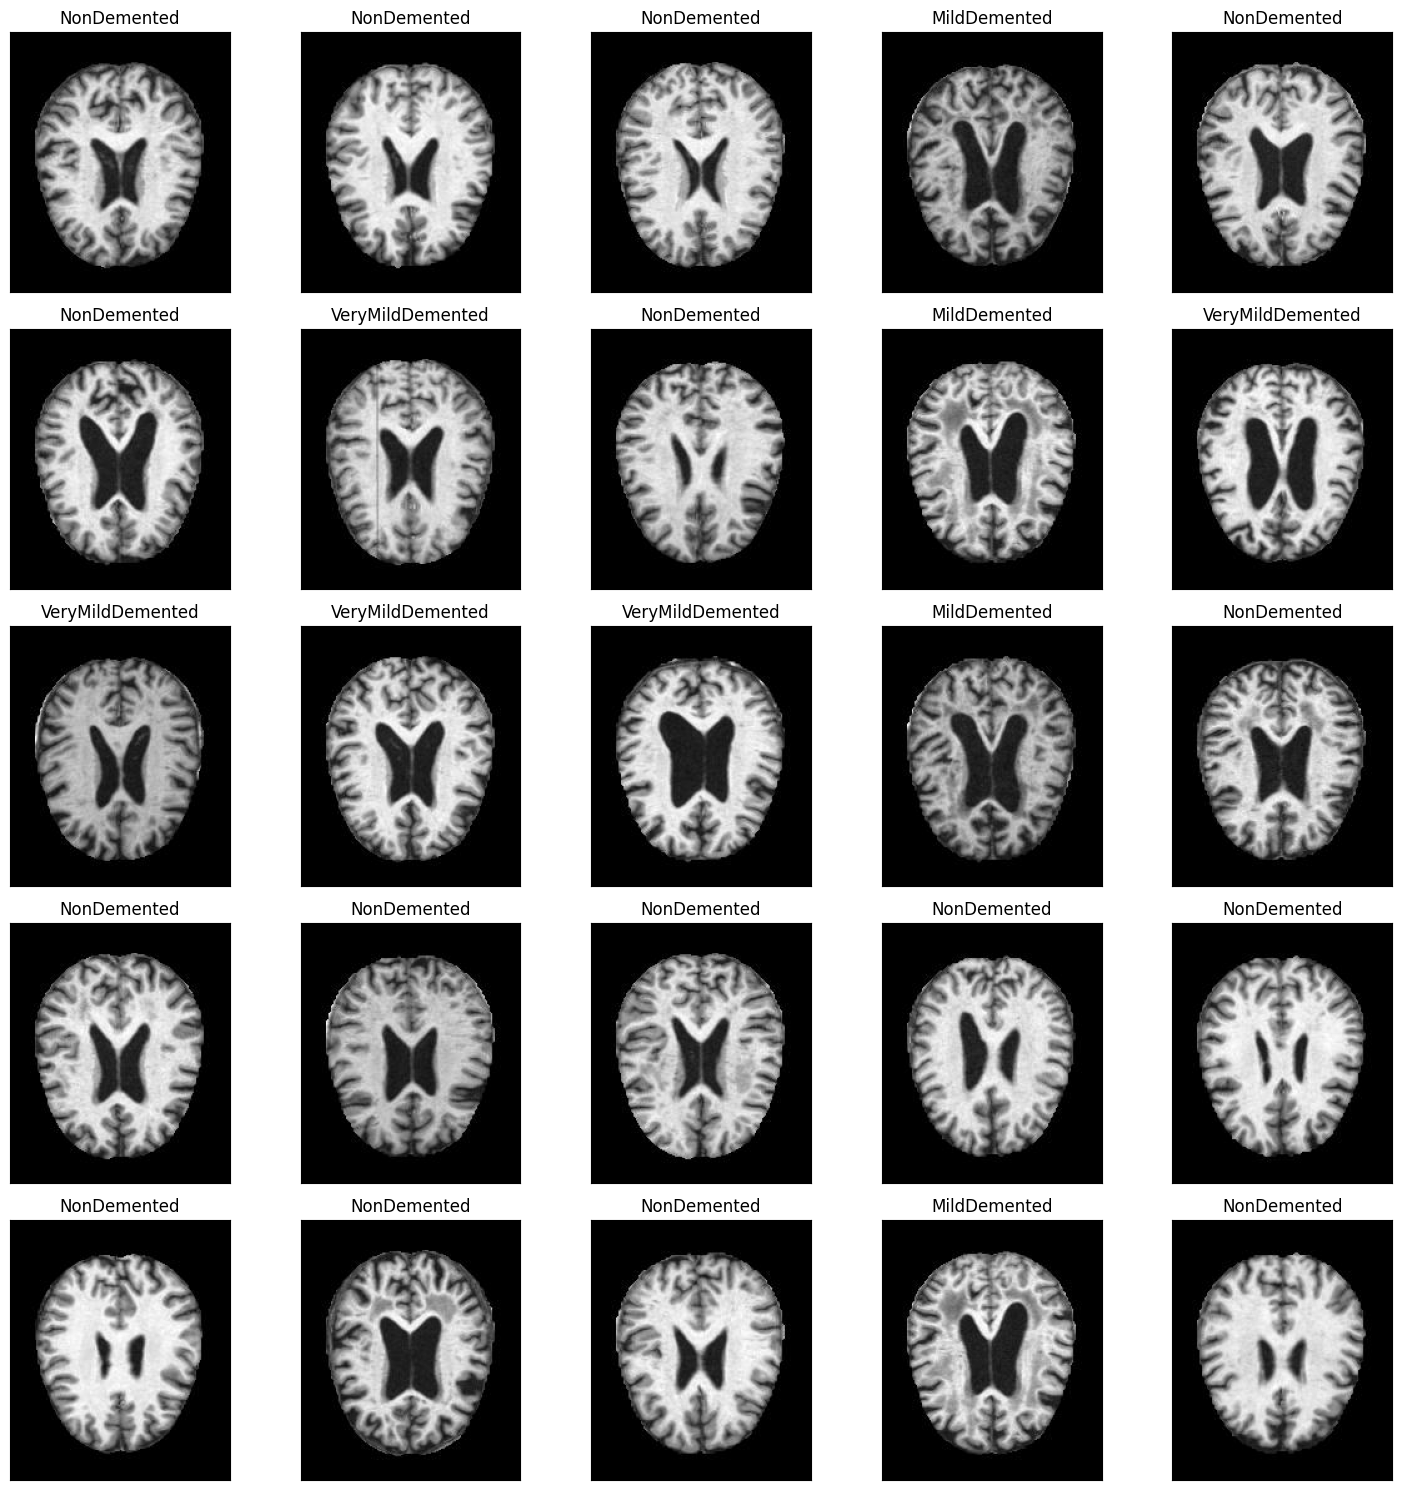

In [ ]:
# Display 20 picture of the dataset with their labels
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(15, 15),
                        subplot_kw={'xticks': [], 'yticks': []})
for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(test_df.Filepath[i]), cmap = 'gray')
    ax.set_title(test_df.Label[i])
plt.tight_layout()
plt.show()

In [ ]:
if test_df.empty:
    print("Test DataFrame is empty. Skipping flow_from_dataframe.")
else:
    # Perform flow_from_dataframe operation here
    pass

In [ ]:
test_filepaths = [
    '/content/drive/MyDrive/AugmentedAlzheimerDataset/test/MildDemented/1 (2).jpg',
    '/content/drive/MyDrive/AugmentedAlzheimerDataset/test/ModerateDemented/9 (2).jpg',
    '/content/drive/MyDrive/AugmentedAlzheimerDataset/test/NonDemented/1 (9).jpg',
    '/content/drive/MyDrive/AugmentedAlzheimerDataset/test/VeryMildDemented/1 (2).jpg'
]

test_labels = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

test_df = pd.DataFrame({'Filepath': test_filepaths, 'Label': test_labels})


In [ ]:
import os
import pandas as pd
from pathlib import Path
import tensorflow as tf

BATCH_SIZE = 32

# Define paths to your training and testing sets as Path objects (FIXED: added missing quotes)
train_dir = Path(r'C:/Users/prash/Desktop/AugmentedAlzheimerDataset/train')
test_dir = Path(r'C:/Users/prash/Desktop/AugmentedAlzheimerDataset/test')

# Verify directories exist
print(f"Train directory exists: {train_dir.exists()}")
print(f"Test directory exists: {test_dir.exists()}")

# Get filepaths and labels for the training set
train_filepaths = []
train_labels = []

if train_dir.exists():
    for file in train_dir.glob('**/*.jpg'):
        train_filepaths.append(str(file))
        train_labels.append(file.parts[-2])  # Get parent folder name as label

    train_df = pd.DataFrame({'Filepath': train_filepaths, 'Label': train_labels})
    train_df = train_df.sample(frac=1).reset_index(drop=True)  # Shuffle the dataframe
    print(f"Training samples: {len(train_df)}")
    print(train_df.head(3))
    print("\nTraining class distribution:")
    print(train_df['Label'].value_counts())
else:
    print("Train directory not found!")
    train_df = pd.DataFrame()

# Get filepaths and labels for the testing set
test_filepaths = []
test_labels = []

if test_dir.exists():
    for file in test_dir.glob('**/*.jpg'):
        test_filepaths.append(str(file))
        test_labels.append(file.parts[-2])  # Get parent folder name as label

    test_df = pd.DataFrame({'Filepath': test_filepaths, 'Label': test_labels})
    if not test_df.empty:
        test_df = test_df.sample(frac=1).reset_index(drop=True)  # Shuffle the dataframe
        print(f"\nTesting samples: {len(test_df)}")
        print(test_df.head(3))
        print("\nTesting class distribution:")
        print(test_df['Label'].value_counts())
    else:
        print("Test DataFrame is empty.")
else:
    print("Test directory not found!")
    test_df = pd.DataFrame()

# Create data generators only if dataframes are not empty
if not train_df.empty:
    train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1.0/255.0,
        validation_split=0.2  # Optional: for train/validation split
    )

    test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1.0/255.0
    )

    train_images = train_generator.flow_from_dataframe(
        dataframe=train_df,
        x_col='Filepath',
        y_col='Label',
        target_size=(128, 128),
        color_mode='rgb',
        class_mode='categorical',
        batch_size=BATCH_SIZE,
        seed=42,
        shuffle=True  # Changed to True for training
    )

    # If you want validation split
    validation_images = train_generator.flow_from_dataframe(
        dataframe=train_df,
        x_col='Filepath',
        y_col='Label',
        target_size=(128, 128),
        color_mode='rgb',
        class_mode='categorical',
        batch_size=BATCH_SIZE,
        seed=42,
        shuffle=True,
        subset='validation'
    )

    if not test_df.empty:
        test_images = test_generator.flow_from_dataframe(
            dataframe=test_df,
            x_col='Filepath',
            y_col='Label',
            target_size=(128, 128),
            color_mode='rgb',
            class_mode='categorical',
            batch_size=BATCH_SIZE,
            shuffle=False  # Keep False for testing
        )

    print("\nClass indices:", train_images.class_indices)
else:
    print("Cannot create data generators - training dataframe is empty.")

Train directory exists: True
Test directory exists: True
Training samples: 33984
                                            Filepath             Label
0  C:\Users\prash\Desktop\AugmentedAlzheimerDatas...  ModerateDemented
1  C:\Users\prash\Desktop\AugmentedAlzheimerDatas...  VeryMildDemented
2  C:\Users\prash\Desktop\AugmentedAlzheimerDatas...       NonDemented

Training class distribution:
NonDemented         9600
VeryMildDemented    8960
MildDemented        8960
ModerateDemented    6464
Name: Label, dtype: int64

Testing samples: 1279
                                            Filepath         Label
0  C:\Users\prash\Desktop\AugmentedAlzheimerDatas...  MildDemented
1  C:\Users\prash\Desktop\AugmentedAlzheimerDatas...   NonDemented
2  C:\Users\prash\Desktop\AugmentedAlzheimerDatas...   NonDemented

Testing class distribution:
NonDemented         640
VeryMildDemented    448
MildDemented        179
ModerateDemented     12
Name: Label, dtype: int64
Found 33984 validated image filenames



Model: "cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 16)      448       
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 16)      2320      
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 16)        0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 64, 64, 32)        4640      
                                                                 
 conv2d_3 (Conv2D)           (None, 64, 64, 32)        9248      
                                                                 
 batch_normalization (Batch  (None, 64, 64, 32)        128       
 Normalization)                                        

C:\Users\prash\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1062/1062 [==============================] - 609s 561ms/step - loss: 1.2818 - acc: 0.4194 - auc: 0.7005 - f1_score: 0.4212 - val_loss: 1.3045 - val_acc: 0.5004 - val_auc: 0.8275 - val_f1_score: 0.1668
Epoch 2/100
1062/1062 [==============================] - ETA: 0s - loss: 0.8007 - acc: 0.6248 - auc: 0.8792 - f1_score: 0.6402   
Epoch 2: val_loss improved from 1.30449 to 0.99542, saving model to .\best_weights.hdf5
1062/1062 [==============================] - 570s 537ms/step - loss: 0.8007 - acc: 0.6248 - auc: 0.8792 - f1_score: 0.6402 - val_loss: 0.9954 - val_acc: 0.5051 - val_auc: 0.8050 - val_f1_score: 0.6201
Epoch 3/100
1062/1062 [==============================] - ETA: 0s - loss: 0.6707 - acc: 0.6981 - auc: 0.9168 - f1_score: 0.7156   
Epoch 3: val_loss improved from 0.99542 to 0.81951, saving model to .\best_weights.hdf5
1062/1062 [==============================] - 559s 526ms/step - loss: 0.6707 - acc: 0.6981 - auc: 0.9168 - f1_score: 0.7156 - val_loss: 0.8195 - val_acc: 0.6013 - 

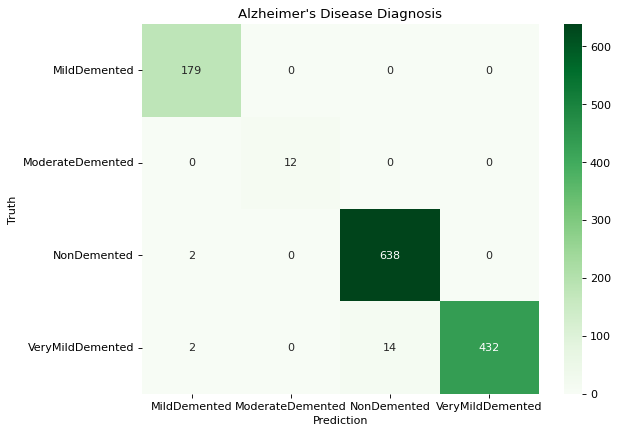

AttributeError: module 'tensorflow_addons.metrics' has no attribute 'BalancedAccuracy'

In [ ]:
custom_model = Sequential([
    Input(shape=(*IMAGE_SIZE, 3)),
    Conv2D(16, 3, activation='relu', padding='same'),
    Conv2D(16, 3, activation='relu', padding='same'),
    MaxPool2D(),
    Conv2D(32, 3, activation='relu', padding='same'),
    Conv2D(32, 3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(),
    Conv2D(64, 3, activation='relu', padding='same'),
    Conv2D(64, 3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(),
    Conv2D(128, 3, activation='relu', padding='same'),
    Conv2D(128, 3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(),
    Conv2D(256, 3, activation='relu', padding='same'),
    Conv2D(256, 3, activation='relu', padding='same', name='last_conv_layer'),
    BatchNormalization(),
    MaxPool2D(),
    Flatten(),
    Dropout(0.2),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.7),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(4, activation='softmax')
], name="cnn_model")

custom_model.summary()

OPT = tf.keras.optimizers.Adam(learning_rate=0.001)
METRICS = [tf.keras.metrics.CategoricalAccuracy(name='acc'), tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.F1Score(num_classes=4, average='weighted')]
custom_model.compile(optimizer=OPT, loss=tf.losses.CategoricalCrossentropy(), metrics=METRICS)

earlystopping = EarlyStopping(monitor='val_loss', mode='min', patience=10, verbose=1)
filepath = './best_weights.hdf5'
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', mode='min', save_best_only=True, verbose=1)
callback_list = [earlystopping, checkpoint]

# Fit the training data to the model and validate it using the validation data
custom_model_history = custom_model.fit(train_images, validation_data=test_images, callbacks=callback_list, epochs=EPOCHS)

test_scores = custom_model.evaluate(test_images)
print("Testing Accuracy: %.2f%%" % (test_scores[1] * 100))

pred_labels = custom_model.predict(test_images)

def roundoff(arr):
    """To round off according to the argmax of each predicted label array."""
    arr[np.argwhere(arr != arr.max())] = 0
    arr[np.argwhere(arr == arr.max())] = 1
    return arr

for labels in pred_labels:
    labels = roundoff(labels)

pred = np.argmax(pred_labels, axis=1)

print(classification_report(test_images.classes, pred, target_names=CLASSES))

# Plot the confusion matrix to understand the classification in detail
conf_arr = confusion_matrix(test_images.classes, pred)

plt.figure(figsize=(8, 6), dpi=80, facecolor='w', edgecolor='k')
ax = sns.heatmap(conf_arr, cmap='Greens', annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Alzheimer\'s Disease Diagnosis')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.show(ax)


In [ ]:
# Printing some other classification metrics
from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef

# Calculate metrics using sklearn
BAS = balanced_accuracy_score(test_images.classes, pred)
MCC = matthews_corrcoef(test_images.classes, pred)

print("Balanced Accuracy Score: {:.2f}%".format(BAS * 100))
print("Matthew's Correlation Coefficient: {:.2f}%".format(MCC * 100))

custom_model.save('custom_cnn_(87.04%).h5')

Balanced Accuracy Score: 99.03%
Matthew's Correlation Coefficient: 97.70%


C:\Users\prash\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Generating comprehensive model evaluation...
MODEL PERFORMANCE METRICS


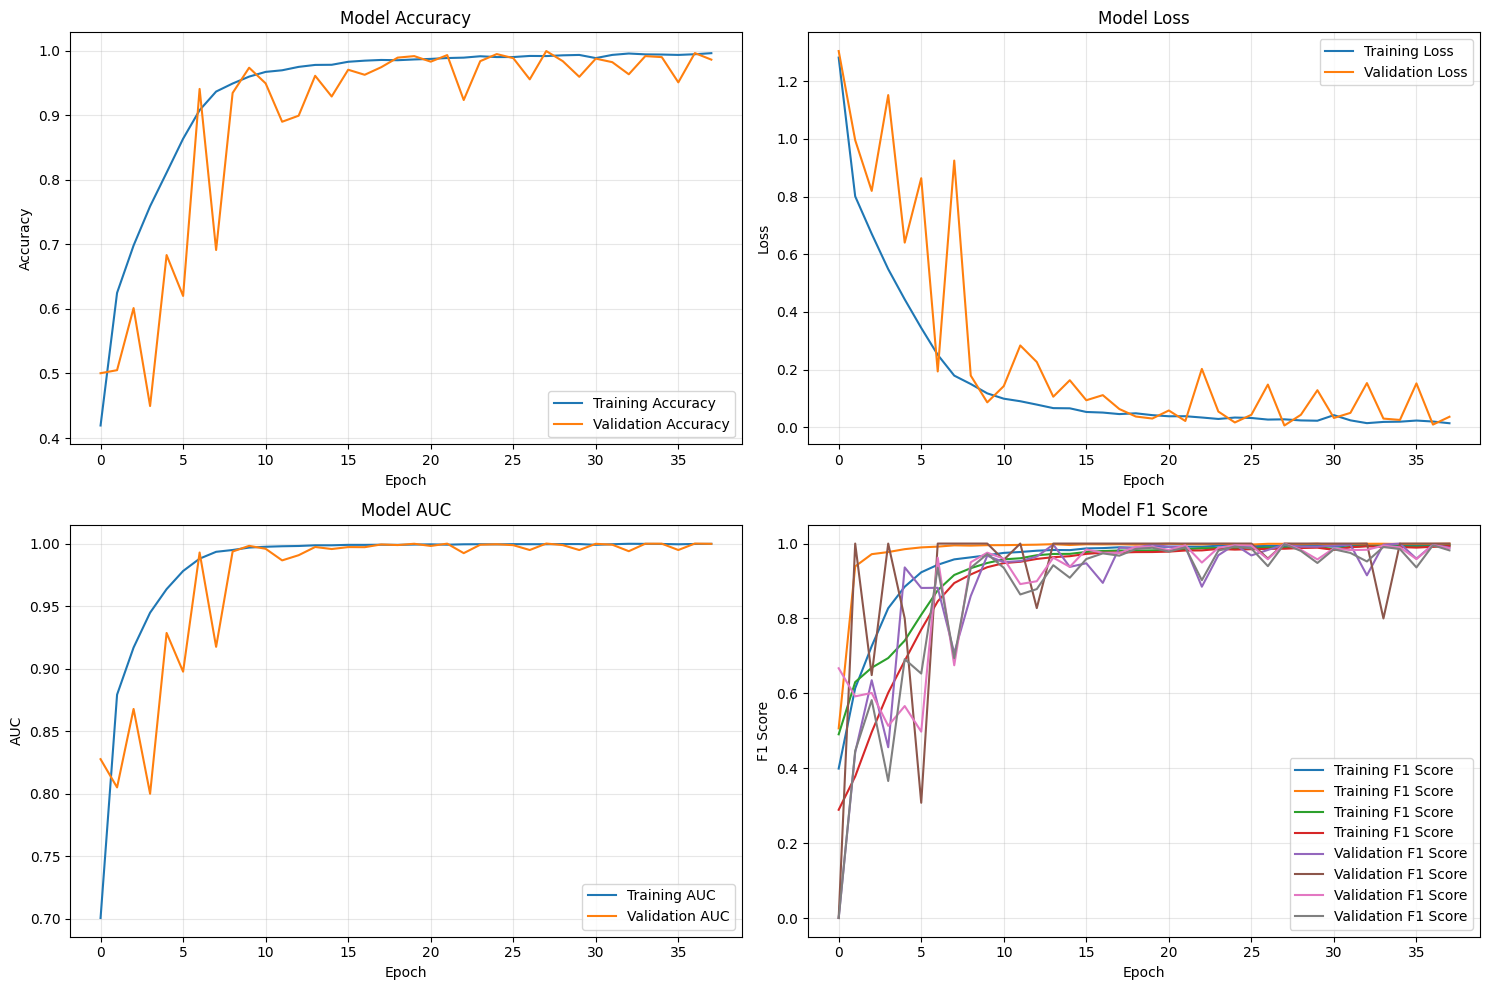


Generating ROC Curve...
40/40 [==============================] - 6s 137ms/step


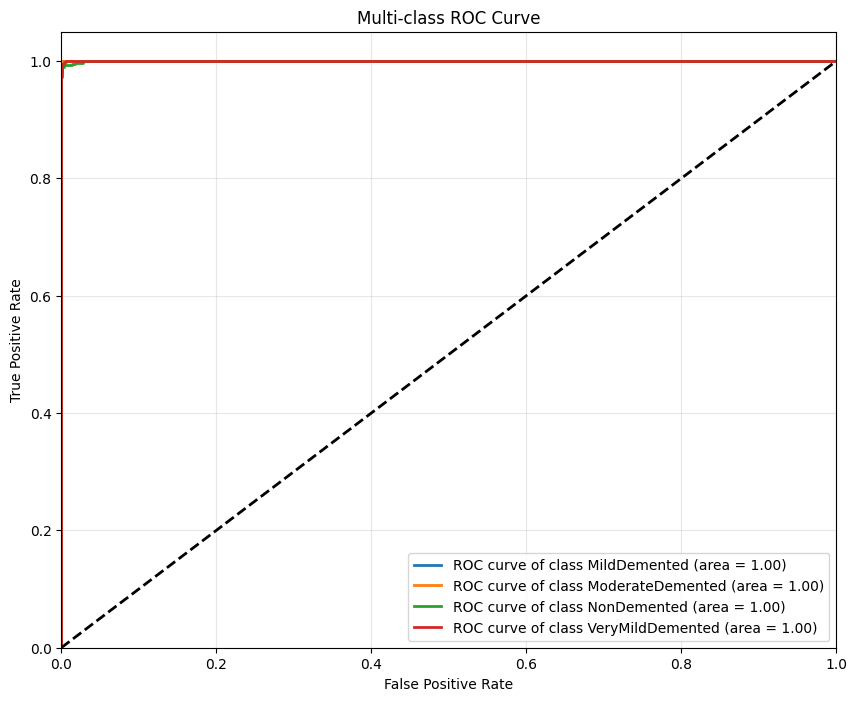


Generating Confusion Matrix...
40/40 [==============================] - 5s 130ms/step


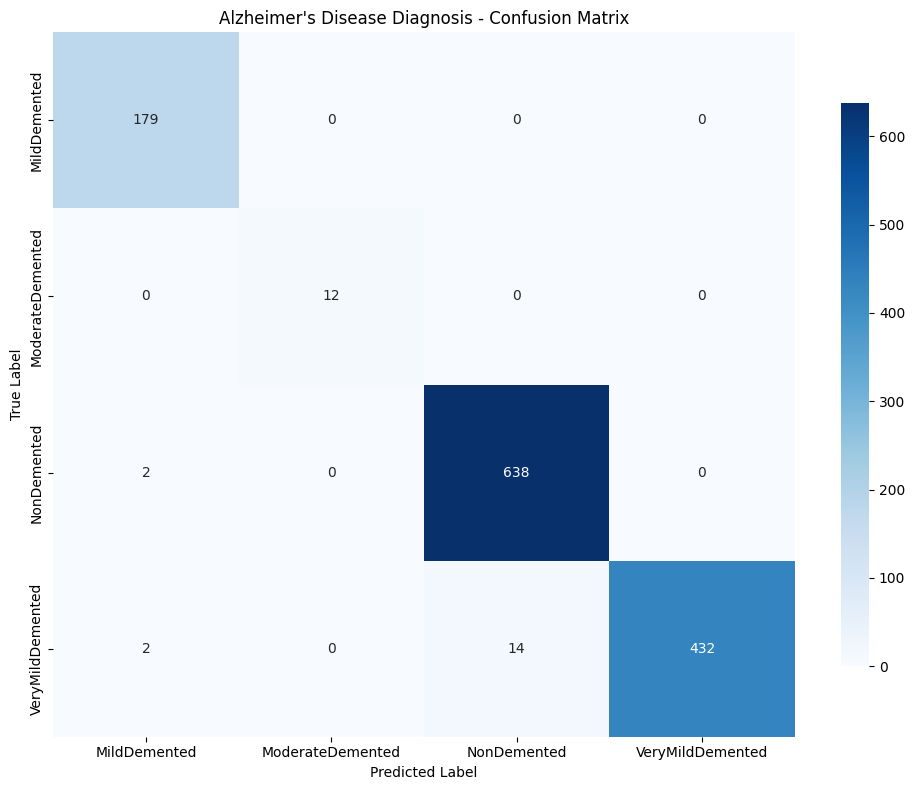

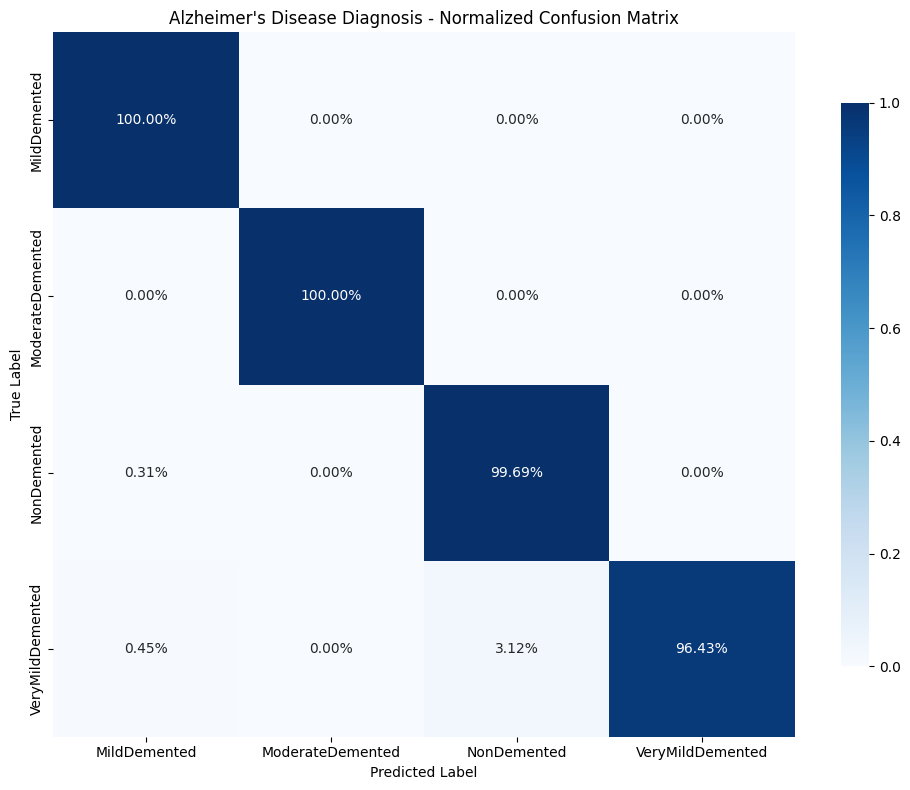

40/40 [==============================] - 5s 112ms/step

ADDITIONAL METRICS
Balanced Accuracy Score: 99.03%
Matthew's Correlation Coefficient: 97.70%
Final Test Accuracy: 98.59%
Final Test Loss: 0.0362

DETAILED CLASSIFICATION REPORT
                  precision    recall  f1-score   support

    MildDemented       0.98      1.00      0.99       179
ModerateDemented       1.00      1.00      1.00        12
     NonDemented       0.98      1.00      0.99       640
VeryMildDemented       1.00      0.96      0.98       448

        accuracy                           0.99      1279
       macro avg       0.99      0.99      0.99      1279
    weighted avg       0.99      0.99      0.99      1279

40/40 [==============================] - 6s 149ms/step

Misclassified samples: 18/1279 (1.41%)

First 10 misclassified samples:
File: C:\Users\prash\Desktop\AugmentedAlzheimerDataset\test\VeryMildDemented\31 (2).jpg
  True: VeryMildDemented, Predicted: NonDemented, Confidence: 0.958

File: C:\Users\

C:\Users\prash\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Model saved as: custom_cnn_(98.59%).h5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, balanced_accuracy_score, matthews_corrcoef
from sklearn.preprocessing import label_binarize
import tensorflow as tf

# 1. ROC Curve
def plot_roc_curve(model, test_images, CLASSES):
    # Get predictions
    y_pred = model.predict(test_images)
    y_true = test_images.classes

    # Binarize the labels for ROC curve
    y_true_bin = label_binarize(y_true, classes=list(range(len(CLASSES))))

    # Compute ROC curve and ROC area for each class
    fpr = {}
    tpr = {}
    roc_auc = {}

    plt.figure(figsize=(10, 8))

    for i in range(len(CLASSES)):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

        plt.plot(fpr[i], tpr[i], lw=2,
                 label='ROC curve of class {0} (area = {1:0.2f})'.format(CLASSES[i], roc_auc[i]))

    # Plot diagonal line
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-class ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    return fpr, tpr, roc_auc

# 2. Enhanced Confusion Matrix
def plot_enhanced_confusion_matrix(model, test_images, CLASSES):
    # Get predictions
    pred_labels = model.predict(test_images)
    pred = np.argmax(pred_labels, axis=1)
    true_labels = test_images.classes

    # Calculate confusion matrix
    conf_arr = confusion_matrix(true_labels, pred)

    # Plot confusion matrix with counts
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_arr, cmap='Blues', annot=True, fmt='d',
                xticklabels=CLASSES, yticklabels=CLASSES,
                cbar_kws={'shrink': 0.8})
    plt.title('Alzheimer\'s Disease Diagnosis - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    # Plot normalized confusion matrix
    conf_arr_percent = conf_arr.astype('float') / conf_arr.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_arr_percent, cmap='Blues', annot=True, fmt='.2%',
                xticklabels=CLASSES, yticklabels=CLASSES,
                cbar_kws={'shrink': 0.8})
    plt.title('Alzheimer\'s Disease Diagnosis - Normalized Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    return conf_arr

# 3. Training History Graphs
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Training and validation accuracy
    axes[0, 0].plot(history.history['acc'], label='Training Accuracy')
    axes[0, 0].plot(history.history['val_acc'], label='Validation Accuracy')
    axes[0, 0].set_title('Model Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # Training and validation loss
    axes[0, 1].plot(history.history['loss'], label='Training Loss')
    axes[0, 1].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # Training and validation AUC
    if 'auc' in history.history:
        axes[1, 0].plot(history.history['auc'], label='Training AUC')
        axes[1, 0].plot(history.history['val_auc'], label='Validation AUC')
        axes[1, 0].set_title('Model AUC')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('AUC')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)
    else:
        axes[1, 0].set_visible(False)

    # F1 Score (if available)
    if 'f1_score' in history.history:
        axes[1, 1].plot(history.history['f1_score'], label='Training F1 Score')
        axes[1, 1].plot(history.history['val_f1_score'], label='Validation F1 Score')
        axes[1, 1].set_title('Model F1 Score')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('F1 Score')
        axes[1, 1].legend()
        axes[1, 1].grid(alpha=0.3)
    else:
        axes[1, 1].set_visible(False)

    plt.tight_layout()
    plt.show()

# 4. Combined Metrics Visualization
def plot_all_metrics(model, history, test_images, CLASSES):
    print("=" * 60)
    print("MODEL PERFORMANCE METRICS")
    print("=" * 60)

    # Plot training history
    plot_training_history(history)

    # Plot ROC curve
    print("\nGenerating ROC Curve...")
    plot_roc_curve(model, test_images, CLASSES)

    # Plot confusion matrix
    print("\nGenerating Confusion Matrix...")
    conf_arr = plot_enhanced_confusion_matrix(model, test_images, CLASSES)

    # Additional metrics
    pred_labels = model.predict(test_images)
    pred = np.argmax(pred_labels, axis=1)
    true_labels = test_images.classes

    # Calculate and display additional metrics using sklearn (CORRECTED)
    bas_score = balanced_accuracy_score(true_labels, pred)
    mcc_score = matthews_corrcoef(true_labels, pred)

    print("\n" + "=" * 40)
    print("ADDITIONAL METRICS")
    print("=" * 40)
    print(f"Balanced Accuracy Score: {bas_score * 100:.2f}%")
    print(f"Matthew's Correlation Coefficient: {mcc_score * 100:.2f}%")

    # Final test accuracy
    test_scores = model.evaluate(test_images, verbose=0)
    print(f"Final Test Accuracy: {test_scores[1] * 100:.2f}%")
    print(f"Final Test Loss: {test_scores[0]:.4f}")

    # Classification report
    print("\n" + "=" * 40)
    print("DETAILED CLASSIFICATION REPORT")
    print("=" * 40)
    print(classification_report(true_labels, pred, target_names=CLASSES))

# 5. Prediction Analysis
def analyze_predictions(model, test_images, CLASSES):
    # Get predictions and true labels
    pred_probs = model.predict(test_images)
    pred_labels = np.argmax(pred_probs, axis=1)
    true_labels = test_images.classes

    # Get filepaths for error analysis
    test_files = test_images.filenames

    # Find misclassified samples
    misclassified_idx = np.where(pred_labels != true_labels)[0]

    print(f"\nMisclassified samples: {len(misclassified_idx)}/{len(true_labels)} "
          f"({len(misclassified_idx)/len(true_labels)*100:.2f}%)")

    if len(misclassified_idx) > 0:
        print("\nFirst 10 misclassified samples:")
        for i in misclassified_idx[:10]:
            true_class = CLASSES[true_labels[i]]
            pred_class = CLASSES[pred_labels[i]]
            confidence = np.max(pred_probs[i])
            print(f"File: {test_files[i]}")
            print(f"  True: {true_class}, Predicted: {pred_class}, Confidence: {confidence:.3f}")
            print()

# Usage - Add this after your existing code:
# Define your classes (make sure this matches your dataset)
CLASSES = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']  # Adjust based on your actual class names

# Generate all plots and metrics
print("Generating comprehensive model evaluation...")
plot_all_metrics(custom_model, custom_model_history, test_images, CLASSES)

# Additional prediction analysis
analyze_predictions(custom_model, test_images, CLASSES)

# Save the final model with accuracy in filename
final_accuracy = custom_model.evaluate(test_images, verbose=0)[1]
custom_model.save(f'custom_cnn_({final_accuracy*100:.2f}%).h5')
print(f"\nModel saved as: custom_cnn_({final_accuracy*100:.2f}%).h5")

In [ ]:
pip install statsmodels

Running comprehensive model analysis...
COMPREHENSIVE MODEL ANALYSIS

CONFIDENCE ANALYSIS
Overall Confidence Statistics:
  Mean Confidence: 0.9905
  Std Confidence: 0.0492
  Min Confidence: 0.5219
  Max Confidence: 1.0000

Confidence by Prediction Correctness:
  Correct predictions: 1261 samples
    Mean confidence: 0.9934
    Std confidence: 0.0384
  Incorrect predictions: 18 samples
    Mean confidence: 0.7857
    Std confidence: 0.1612

Confidence Threshold Analysis:
  Threshold 0.5: Accuracy = 0.9859, Coverage = 1.0000
  Threshold 0.7: Accuracy = 0.9921, Coverage = 0.9867
  Threshold 0.9: Accuracy = 0.9944, Coverage = 0.9734


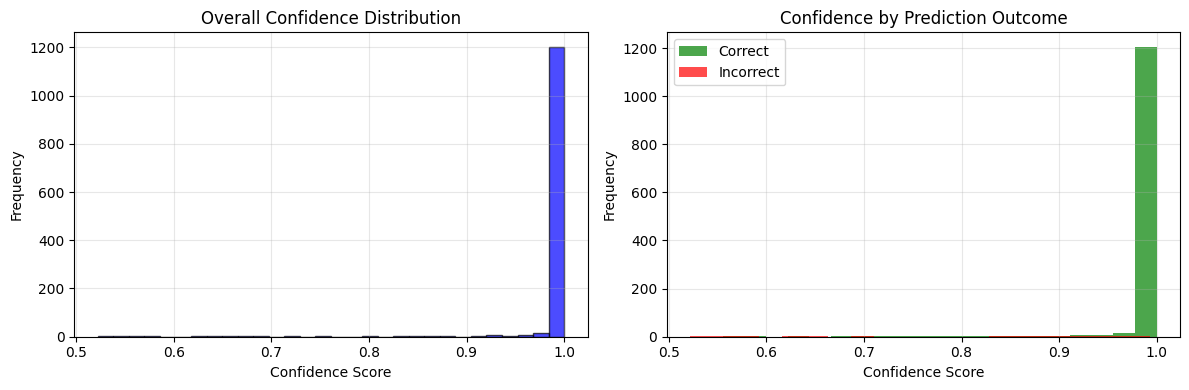


ADVANCED CLASSIFICATION METRICS
Cohen's Kappa: 0.9768
Log Loss: 0.0362
Hamming Loss: 0.0141
Jaccard Score (Macro): 0.9795
  MildDemented: 0.9781
  ModerateDemented: 1.0000
  NonDemented: 0.9755
  VeryMildDemented: 0.9643
Average Precision (Macro): 0.9999
  MildDemented: 1.0000
  ModerateDemented: 1.0000
  NonDemented: 0.9998
  VeryMildDemented: 0.9999
Balanced Accuracy: 0.9903

PER-CLASS DETAILED ANALYSIS
                  Precision  Recall  F1-Score  Support  Avg Confidence
MildDemented         0.9781  1.0000    0.9890    179.0          0.9993
ModerateDemented     1.0000  1.0000    1.0000     12.0          1.0000
NonDemented          0.9785  0.9969    0.9876    640.0          0.9966
VeryMildDemented     1.0000  0.9643    0.9818    448.0          0.9550
Macro Avg            0.9892  0.9903    0.9896   1279.0          0.9877


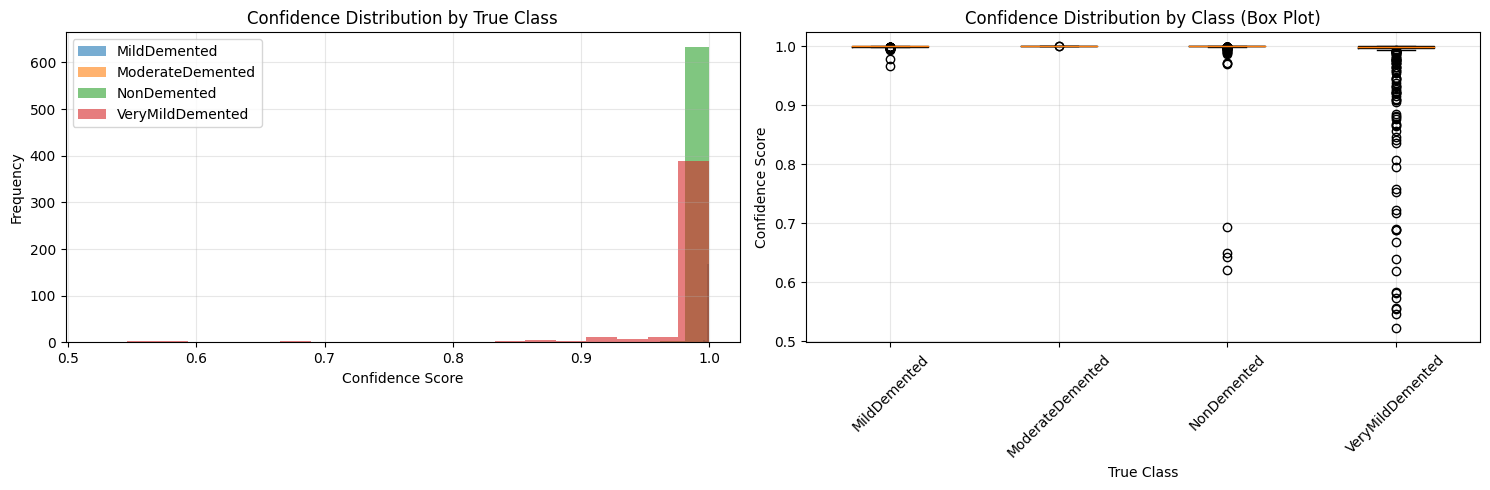


MODEL CALIBRATION ANALYSIS


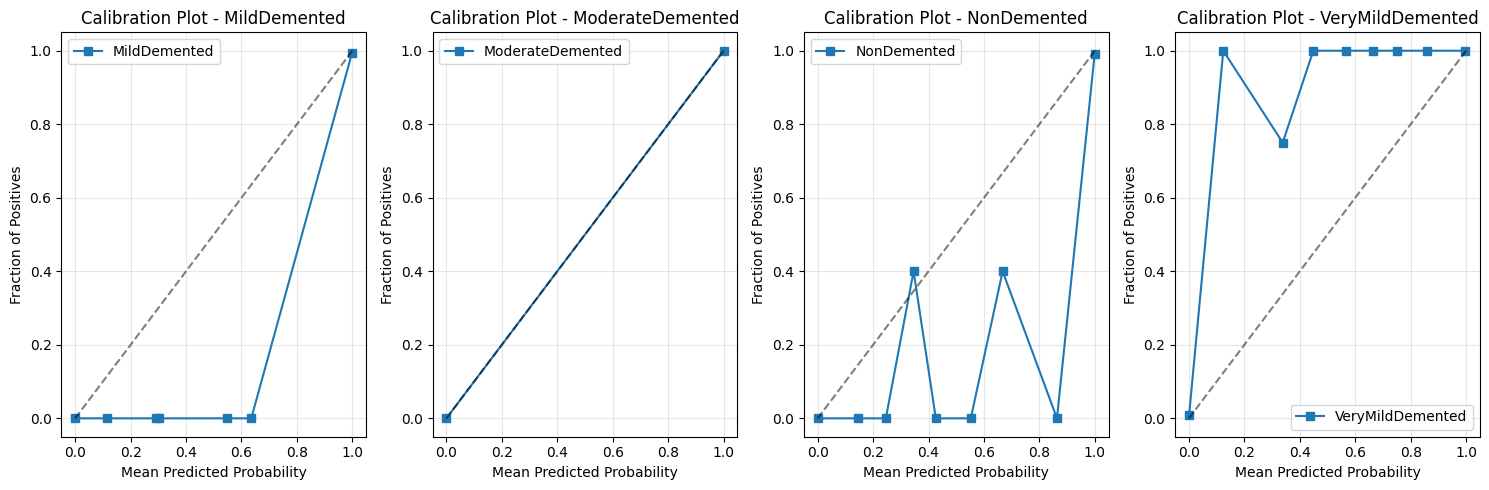

Expected Calibration Error (per class):
  MildDemented: 0.2706
  ModerateDemented: 0.0000
  NonDemented: 0.2850
  VeryMildDemented: 0.3345

DETAILED ERROR ANALYSIS
Most Common Misclassifications:
  VeryMildDemented → NonDemented: 14 samples
  NonDemented → MildDemented: 2 samples
  VeryMildDemented → MildDemented: 2 samples

Confidence-based Error Analysis:
  Low confidence correct predictions (<0.7): 9
  High confidence errors (≥0.7): 10

TRAINING PROCESS ANALYSIS
Final Training Accuracy: 0.9959
Final Validation Accuracy: 0.9859
Final Training Loss: 0.0137
Final Validation Loss: 0.0362

Overfitting Analysis:
  Accuracy gap (train - val): 0.0100
  Loss gap (val - train): 0.0224

ADDITIONAL ANALYSES
Accuracy Confidence Interval (95%): [0.9795, 0.9924]
Model Complexity Analysis:
  Total parameters: 3,355,348
  Trainable parameters: 3,352,980
  Non-trainable parameters: 2,368


(3355348, 3352980, 2368)

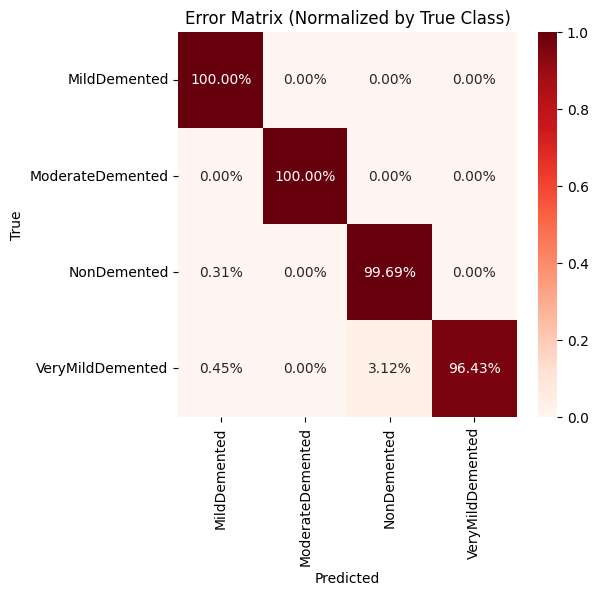

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_recall_curve, average_precision_score, cohen_kappa_score
from sklearn.metrics import log_loss, hamming_loss, jaccard_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize
from scipy.stats import mode
import scipy.stats as stats

def comprehensive_model_analysis(model, test_images, CLASSES, history=None):
    """
    Comprehensive model analysis with additional metrics and visualizations
    """
    print("=" * 70)
    print("COMPREHENSIVE MODEL ANALYSIS")
    print("=" * 70)

    # Get predictions and true labels
    y_pred_proba = model.predict(test_images, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = test_images.classes

    # Ensure y_true and y_pred are numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Confidence analysis
    confidence_scores = np.max(y_pred_proba, axis=1)
    confidence_analysis(y_true, y_pred, confidence_scores, CLASSES)

    # Advanced classification metrics
    advanced_classification_metrics(y_true, y_pred, y_pred_proba, CLASSES)

    # Per-class detailed analysis
    per_class_analysis(y_true, y_pred, y_pred_proba, CLASSES)

    # Confidence distribution by class
    confidence_distribution(y_true, confidence_scores, CLASSES)

    # Model calibration analysis
    calibration_analysis(y_true, y_pred_proba, CLASSES)

    # Error analysis
    error_analysis(y_true, y_pred, confidence_scores, CLASSES, test_images)

    # Training analysis (if history is provided)
    if history is not None:
        training_analysis(history)

def confidence_analysis(y_true, y_pred, confidence_scores, CLASSES):
    """Analyze model confidence patterns"""
    print("\n" + "=" * 50)
    print("CONFIDENCE ANALYSIS")
    print("=" * 50)

    # Overall confidence statistics
    print(f"Overall Confidence Statistics:")
    print(f"  Mean Confidence: {np.mean(confidence_scores):.4f}")
    print(f"  Std Confidence: {np.std(confidence_scores):.4f}")
    print(f"  Min Confidence: {np.min(confidence_scores):.4f}")
    print(f"  Max Confidence: {np.max(confidence_scores):.4f}")

    # Confidence by correctness
    correct_predictions = (y_true == y_pred)
    correct_confidence = confidence_scores[correct_predictions]
    incorrect_confidence = confidence_scores[~correct_predictions]

    print(f"\nConfidence by Prediction Correctness:")
    print(f"  Correct predictions: {len(correct_confidence)} samples")
    if len(correct_confidence) > 0:
        print(f"    Mean confidence: {np.mean(correct_confidence):.4f}")
        print(f"    Std confidence: {np.std(correct_confidence):.4f}")

    print(f"  Incorrect predictions: {len(incorrect_confidence)} samples")
    if len(incorrect_confidence) > 0:
        print(f"    Mean confidence: {np.mean(incorrect_confidence):.4f}")
        print(f"    Std confidence: {np.std(incorrect_confidence):.4f}")

    # Confidence thresholds analysis
    confidence_thresholds = [0.5, 0.7, 0.9]
    print(f"\nConfidence Threshold Analysis:")
    for threshold in confidence_thresholds:
        high_conf_indices = confidence_scores >= threshold
        high_conf_correct = np.sum((y_true == y_pred) & high_conf_indices)
        high_conf_total = np.sum(high_conf_indices)

        if high_conf_total > 0:
            accuracy_at_threshold = high_conf_correct / high_conf_total
            coverage = high_conf_total / len(y_true)
            print(f"  Threshold {threshold}: Accuracy = {accuracy_at_threshold:.4f}, Coverage = {coverage:.4f}")
        else:
            print(f"  Threshold {threshold}: No predictions above threshold")

    # Plot confidence distribution
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.hist(confidence_scores, bins=30, alpha=0.7, color='blue', edgecolor='black')
    plt.xlabel('Confidence Score')
    plt.ylabel('Frequency')
    plt.title('Overall Confidence Distribution')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    if len(correct_confidence) > 0:
        plt.hist(correct_confidence, bins=20, alpha=0.7, label='Correct', color='green')
    if len(incorrect_confidence) > 0:
        plt.hist(incorrect_confidence, bins=20, alpha=0.7, label='Incorrect', color='red')
    plt.xlabel('Confidence Score')
    plt.ylabel('Frequency')
    plt.title('Confidence by Prediction Outcome')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def advanced_classification_metrics(y_true, y_pred, y_pred_proba, CLASSES):
    """Calculate advanced classification metrics"""
    print("\n" + "=" * 50)
    print("ADVANCED CLASSIFICATION METRICS")
    print("=" * 50)

    # Cohen's Kappa
    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"Cohen's Kappa: {kappa:.4f}")

    # Log Loss
    logloss = log_loss(y_true, y_pred_proba)
    print(f"Log Loss: {logloss:.4f}")

    # Hamming Loss
    hamming = hamming_loss(y_true, y_pred)
    print(f"Hamming Loss: {hamming:.4f}")

    # Jaccard Score (per class)
    jaccard_per_class = jaccard_score(y_true, y_pred, average=None, zero_division=0)
    jaccard_macro = jaccard_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"Jaccard Score (Macro): {jaccard_macro:.4f}")
    for i, class_name in enumerate(CLASSES):
        print(f"  {class_name}: {jaccard_per_class[i]:.4f}")

    # Average Precision Score (per class)
    y_true_bin = label_binarize(y_true, classes=list(range(len(CLASSES))))
    avg_precision_per_class = average_precision_score(y_true_bin, y_pred_proba, average=None)
    avg_precision_macro = average_precision_score(y_true_bin, y_pred_proba, average='macro')
    print(f"Average Precision (Macro): {avg_precision_macro:.4f}")
    for i, class_name in enumerate(CLASSES):
        print(f"  {class_name}: {avg_precision_per_class[i]:.4f}")

    # Geometric Mean Score (using balanced accuracy)
    from sklearn.metrics import balanced_accuracy_score
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    print(f"Balanced Accuracy: {balanced_acc:.4f}")

def per_class_analysis(y_true, y_pred, y_pred_proba, CLASSES):
    """Detailed analysis for each class"""
    print("\n" + "=" * 50)
    print("PER-CLASS DETAILED ANALYSIS")
    print("=" * 50)

    metrics_df = pd.DataFrame(index=CLASSES)

    for i, class_name in enumerate(CLASSES):
        # Binary indicators for current class
        y_true_binary = (y_true == i)
        y_pred_binary = (y_pred == i)

        # Convert boolean arrays to integers for sklearn metrics
        y_true_binary_int = y_true_binary.astype(int)
        y_pred_binary_int = y_pred_binary.astype(int)

        # Calculate metrics
        precision = precision_score(y_true_binary_int, y_pred_binary_int, zero_division=0)
        recall = recall_score(y_true_binary_int, y_pred_binary_int, zero_division=0)
        f1 = f1_score(y_true_binary_int, y_pred_binary_int, zero_division=0)

        # Support (number of true instances)
        support = np.sum(y_true_binary)

        # Average confidence for this class
        class_confidences = y_pred_proba[y_true_binary, i]
        avg_confidence = np.mean(class_confidences) if len(class_confidences) > 0 else 0

        metrics_df.loc[class_name, 'Precision'] = precision
        metrics_df.loc[class_name, 'Recall'] = recall
        metrics_df.loc[class_name, 'F1-Score'] = f1
        metrics_df.loc[class_name, 'Support'] = support
        metrics_df.loc[class_name, 'Avg Confidence'] = avg_confidence

    # Add macro averages
    metrics_df.loc['Macro Avg'] = metrics_df[['Precision', 'Recall', 'F1-Score']].mean()
    metrics_df.loc['Macro Avg', 'Support'] = metrics_df['Support'].sum()
    metrics_df.loc['Macro Avg', 'Avg Confidence'] = metrics_df['Avg Confidence'].mean()

    print(metrics_df.round(4))

def confidence_distribution(y_true, confidence_scores, CLASSES):
    """Plot confidence distribution by class"""
    plt.figure(figsize=(15, 5))

    # Confidence distribution by true class
    plt.subplot(1, 2, 1)
    for i, class_name in enumerate(CLASSES):
        class_confidences = confidence_scores[y_true == i]
        if len(class_confidences) > 0:
            plt.hist(class_confidences, alpha=0.6, label=class_name, bins=20)
    plt.xlabel('Confidence Score')
    plt.ylabel('Frequency')
    plt.title('Confidence Distribution by True Class')
    plt.legend()
    plt.grid(alpha=0.3)

    # Box plot of confidence by class
    plt.subplot(1, 2, 2)
    confidence_by_class = []
    labels = []
    for i, class_name in enumerate(CLASSES):
        class_confidences = confidence_scores[y_true == i]
        if len(class_confidences) > 0:
            confidence_by_class.append(class_confidences)
            labels.append(class_name)

    if confidence_by_class:  # Check if list is not empty
        plt.boxplot(confidence_by_class, labels=labels)
        plt.xlabel('True Class')
        plt.ylabel('Confidence Score')
        plt.title('Confidence Distribution by Class (Box Plot)')
        plt.xticks(rotation=45)
        plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def calibration_analysis(y_true, y_pred_proba, CLASSES):
    """Analyze model calibration"""
    print("\n" + "=" * 50)
    print("MODEL CALIBRATION ANALYSIS")
    print("=" * 50)

    from sklearn.calibration import calibration_curve

    plt.figure(figsize=(15, 5))

    # Calibration plot for each class
    for i, class_name in enumerate(CLASSES):
        y_true_binary = (y_true == i).astype(int)

        # Only plot if there are positive samples
        if np.sum(y_true_binary) > 0:
            prob_true, prob_pred = calibration_curve(y_true_binary, y_pred_proba[:, i], n_bins=10, strategy='uniform')

            plt.subplot(1, len(CLASSES), i+1)
            plt.plot(prob_pred, prob_true, 's-', label=class_name)
            plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
            plt.xlabel('Mean Predicted Probability')
            plt.ylabel('Fraction of Positives')
            plt.title(f'Calibration Plot - {class_name}')
            plt.legend()
            plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Expected Calibration Error (simplified)
    print("Expected Calibration Error (per class):")
    for i, class_name in enumerate(CLASSES):
        y_true_binary = (y_true == i).astype(int)
        if np.sum(y_true_binary) > 0:
            prob_true, prob_pred = calibration_curve(y_true_binary, y_pred_proba[:, i], n_bins=10, strategy='uniform')
            ece = np.mean(np.abs(prob_true - prob_pred))
            print(f"  {class_name}: {ece:.4f}")
        else:
            print(f"  {class_name}: No positive samples")

def error_analysis(y_true, y_pred, confidence_scores, CLASSES, test_images):
    """Detailed error analysis"""
    print("\n" + "=" * 50)
    print("DETAILED ERROR ANALYSIS")
    print("=" * 50)

    # Confusion between classes
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)

    # Create error matrix (normalized by true class)
    error_matrix = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(error_matrix, annot=True, fmt='.2%', cmap='Reds',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title('Error Matrix (Normalized by True Class)')
    plt.xlabel('Predicted')
    plt.ylabel('True')

    # Most common misclassifications
    misclassifications = []
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            if i != j and cm[i, j] > 0:
                misclassifications.append((CLASSES[i], CLASSES[j], cm[i, j]))

    misclassifications.sort(key=lambda x: x[2], reverse=True)

    print("Most Common Misclassifications:")
    for true_class, pred_class, count in misclassifications[:10]:
        print(f"  {true_class} → {pred_class}: {count} samples")

    # Low confidence correct vs high confidence errors
    threshold = 0.7
    low_conf_correct = np.sum((y_true == y_pred) & (confidence_scores < threshold))
    high_conf_errors = np.sum((y_true != y_pred) & (confidence_scores >= threshold))

    print(f"\nConfidence-based Error Analysis:")
    print(f"  Low confidence correct predictions (<{threshold}): {low_conf_correct}")
    print(f"  High confidence errors (≥{threshold}): {high_conf_errors}")

def training_analysis(history):
    """Analyze training process"""
    print("\n" + "=" * 50)
    print("TRAINING PROCESS ANALYSIS")
    print("=" * 50)

    # Calculate training statistics
    final_train_acc = history.history['acc'][-1]
    final_val_acc = history.history['val_acc'][-1]
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]

    print(f"Final Training Accuracy: {final_train_acc:.4f}")
    print(f"Final Validation Accuracy: {final_val_acc:.4f}")
    print(f"Final Training Loss: {final_train_loss:.4f}")
    print(f"Final Validation Loss: {final_val_loss:.4f}")

    # Overfitting analysis
    accuracy_gap = final_train_acc - final_val_acc
    loss_gap = final_val_loss - final_train_loss

    print(f"\nOverfitting Analysis:")
    print(f"  Accuracy gap (train - val): {accuracy_gap:.4f}")
    print(f"  Loss gap (val - train): {loss_gap:.4f}")

    if accuracy_gap > 0.1:
        print("  ⚠️  Potential overfitting (large accuracy gap)")
    if loss_gap > 0.1:
        print("  ⚠️  Potential overfitting (large loss gap)")

def calculate_confidence_intervals(accuracy, n_samples, confidence_level=0.95):
    """Calculate confidence intervals for accuracy"""
    from statsmodels.stats.proportion import proportion_confint

    lower, upper = proportion_confint(accuracy * n_samples, n_samples, alpha=1-confidence_level)
    return lower, upper

def model_complexity_analysis(model):
    """Analyze model complexity"""
    total_params = model.count_params()
    trainable_params = np.sum([np.prod(v.get_shape()) for v in model.trainable_weights])
    non_trainable_params = total_params - trainable_params

    print(f"Model Complexity Analysis:")
    print(f"  Total parameters: {total_params:,}")
    print(f"  Trainable parameters: {trainable_params:,}")
    print(f"  Non-trainable parameters: {non_trainable_params:,}")

    return total_params, trainable_params, non_trainable_params

# Usage:
print("Running comprehensive model analysis...")
comprehensive_model_analysis(custom_model, test_images, CLASSES, custom_model_history)

print("\n" + "=" * 70)
print("ADDITIONAL ANALYSES")
print("=" * 70)

# Confidence intervals
n_samples = len(test_images.classes)
test_accuracy = custom_model.evaluate(test_images, verbose=0)[1]
lower, upper = calculate_confidence_intervals(test_accuracy, n_samples)
print(f"Accuracy Confidence Interval (95%): [{lower:.4f}, {upper:.4f}]")

# Model complexity
model_complexity_analysis(custom_model)